In [ ]:
# ── Install & imports ─────────────────────────────────────────
!pip install -q timm albumentations openpyxl

import torch, os, copy
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import tqdm
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT_RATE  = 0.4
SEED         = 42
FREEZE_EPOCHS = 5

DISEASE_CLASSES  = ['Bacterial_spot','Early_blight','Late_blight',
                    'Leaf_Mold','Septoria_leaf_spot','healthy']
SEVERITY_CLASSES = ['Early','Mid','Late']
SEV_DIS_CLASSES  = ['Bacterial_spot','Early_blight','Late_blight',
                    'Leaf_Mold','Septoria_leaf_spot']
NUM_DISEASE  = len(DISEASE_CLASSES)
NUM_SEVERITY = len(SEVERITY_CLASSES)

def set_seed(s=SEED):
    import random; random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed()
print("✅ Setup done | Device:", DEVICE)

✅ Setup done | Device: cuda


In [ ]:
# ── Upload your 3 .pth files when prompted ────────────────────
from google.colab import files
print("⬆️  Upload: best_resnet50.pth, single_task_best.pth, last_weight_model.pth")
files.upload()

MTL_PATH = "/content/best_resnet50.pth"
ST_PATH  = "/content/single_task_best.pth"
LW_PATH  = "/content/last_weight_model.pth"

⬆️  Upload: best_resnet50.pth, single_task_best.pth, last_weight_model.pth


Saving best_resnet50.pth to best_resnet50.pth


In [ ]:
# ── Dataset ───────────────────────────────────────────────────
from google.colab import files as cfiles
print("⬆️  Upload kaggle.json")
cfiles.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d janiruwalisingha/tomato-leaf-disease-severity-dataset \
       --path /content/data --unzip
print("✅ Dataset ready")

DISEASE_TRAIN  = '/content/data/disease/train'
DISEASE_VAL    = '/content/data/disease/val'
SEVERITY_TRAIN = '/content/data/severity/train'
SEVERITY_VAL   = '/content/data/severity/valid'

⬆️  Upload kaggle.json


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/janiruwalisingha/tomato-leaf-disease-severity-dataset
License(s): unknown
100% 1.08G/1.08G [01:17<00:00, 15.0MB/s]

✅ Dataset ready


In [ ]:
# ── Transforms ────────────────────────────────────────────────
def get_train_tf():
    return A.Compose([
        A.RandomResizedCrop(size=(IMG_SIZE,IMG_SIZE), scale=(0.7,1.0)),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
        A.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.3,hue=0.1,p=0.6),
        A.GaussNoise(std_range=(0.02,0.1), p=0.3),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def get_val_tf():
    return A.Compose([
        A.Resize(IMG_SIZE,IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

In [ ]:
# ── Datasets ──────────────────────────────────────────────────
class DiseaseDataset(Dataset):
    def __init__(self, root, tf=None):
        self.tf = tf
        self.samples = []
        for i,cls in enumerate(DISEASE_CLASSES):
            d = os.path.join(root, cls)
            if not os.path.isdir(d): continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f), i))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p,l = self.samples[idx]
        img = np.array(Image.open(p).convert('RGB'))
        if self.tf: img = self.tf(image=img)['image']
        return img, l

class SeverityDataset(Dataset):
    def __init__(self, root, tf=None):
        self.tf = tf
        self.samples = []
        for dis in SEV_DIS_CLASSES:
            for sev in SEVERITY_CLASSES:
                d = os.path.join(root, dis, sev)
                if not os.path.isdir(d): continue
                for f in os.listdir(d):
                    if f.lower().endswith(('.jpg','.jpeg','.png')):
                        self.samples.append((
                            os.path.join(d,f),
                            DISEASE_CLASSES.index(dis),
                            SEVERITY_CLASSES.index(sev)
                        ))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p,d,s = self.samples[idx]
        img = np.array(Image.open(p).convert('RGB'))
        if self.tf: img = self.tf(image=img)['image']
        return img, d, s

SEV_TO_DIS = {i: DISEASE_CLASSES.index(c) for i,c in enumerate(SEV_DIS_CLASSES)}

class MTLDataset(Dataset):
    def __init__(self, dis_ds, sev_ds):
        self.samples = []
        for p,dl in dis_ds.samples:
            self.samples.append(dict(path=p,disease=dl,severity=-1,has_sev=False,src='dis'))
        for p,sdl,sl in sev_ds.samples:
            self.samples.append(dict(path=p,disease=sdl,severity=sl,has_sev=True,src='sev'))
        self.dis_tf = dis_ds.tf
        self.sev_tf = sev_ds.tf
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = np.array(Image.open(s['path']).convert('RGB'))
        tf  = self.dis_tf if s['src']=='dis' else self.sev_tf
        if tf: img = tf(image=img)['image']
        return (img,
                torch.tensor(s['disease'],  dtype=torch.long),
                torch.tensor(s['severity'], dtype=torch.long),
                torch.tensor(s['has_sev'],  dtype=torch.bool))

# Build loaders
print("Building datasets...")
dis_tr = DiseaseDataset(DISEASE_TRAIN,  get_train_tf())
dis_vl = DiseaseDataset(DISEASE_VAL,    get_val_tf())
sev_tr = SeverityDataset(SEVERITY_TRAIN, get_train_tf())
sev_vl = SeverityDataset(SEVERITY_VAL,   get_val_tf())

train_dataset = MTLDataset(dis_tr, sev_tr)
val_dataset   = MTLDataset(dis_vl, sev_vl)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Building datasets...
✅ Train batches: 660 | Val batches: 98


In [ ]:
# ── Model Building Blocks (identical to your original) ────────
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(nn.Linear(c,c//r,bias=False),nn.ReLU(),
                                  nn.Linear(c//r,c,bias=False))
    def forward(self, x):
        b,c,_,_ = x.shape
        return x * torch.sigmoid(
            self.fc(self.avg(x).view(b,c)) +
            self.fc(self.max(x).view(b,c))
        ).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3,bias=False)
    def forward(self, x):
        return x * torch.sigmoid(
            self.conv(torch.cat([x.mean(1,True), x.max(1,True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c); self.sa = SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class CrossTaskAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q=nn.Linear(d,d); self.k=nn.Linear(d,d); self.v=nn.Linear(d,d)
        self.norm=nn.LayerNorm(d); self.scale=d**-0.5
    def forward(self, sf, df):
        attn = torch.sigmoid((self.q(sf)*self.k(df)).sum(-1,keepdim=True)*self.scale)
        return self.norm(sf + attn*self.v(df))

class TaskHead(nn.Module):
    def __init__(self, in_f, h, n, drop=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f,h), nn.BatchNorm1d(h), nn.ReLU(),
            nn.Dropout(drop), nn.Linear(h,n))
    def forward(self, x): return self.net(x)

def _feat_dim(backbone):
    with torch.no_grad():
        return backbone(torch.zeros(2,3,IMG_SIZE,IMG_SIZE)).shape[1]

In [ ]:
# ── All 6 Model Variants ──────────────────────────────────────

class TomatoMTL(nn.Module):
    """Full MTL: CBAM + CrossTaskAttention"""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('resnet50',pretrained=False,
                                          num_classes=0,global_pool='')
        fd = _feat_dim(self.backbone)
        self.pool=nn.AdaptiveAvgPool2d(1); self.cbam=CBAM(fd)
        self.dis_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.dis_head=TaskHead(512,256,NUM_DISEASE)
        self.sev_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.cross_attn=CrossTaskAttention(512)
        self.sev_head=TaskHead(512,256,NUM_SEVERITY)
    def freeze_backbone(self,f=True):
        for p in self.backbone.parameters(): p.requires_grad=not f
    def forward(self,x):
        f=self.backbone(x)
        if f.dim()==4: f=self.cbam(f); f=self.pool(f).flatten(1)
        df=self.dis_proj(f); dl=self.dis_head(df)
        sf=self.cross_attn(self.sev_proj(f), df.detach())
        return dl, self.sev_head(sf)

class TomatoMTL_NoCrossAttn(nn.Module):
    """MTL: CBAM only, NO CrossTaskAttention"""
    def __init__(self):
        super().__init__()
        self.backbone=timm.create_model('resnet50',pretrained=True,
                                        num_classes=0,global_pool='')
        fd=_feat_dim(self.backbone)
        self.pool=nn.AdaptiveAvgPool2d(1); self.cbam=CBAM(fd)
        self.dis_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.dis_head=TaskHead(512,256,NUM_DISEASE)
        self.sev_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.sev_head=TaskHead(512,256,NUM_SEVERITY)
    def freeze_backbone(self,f=True):
        for p in self.backbone.parameters(): p.requires_grad=not f
    def forward(self,x):
        f=self.backbone(x)
        if f.dim()==4: f=self.cbam(f); f=self.pool(f).flatten(1)
        dl=self.dis_head(self.dis_proj(f))
        sl=self.sev_head(self.sev_proj(f))   # independent — no cross-attn
        return dl, sl

class TomatoMTL_NoCBAM(nn.Module):
    """MTL: CrossTaskAttention only, NO CBAM"""
    def __init__(self):
        super().__init__()
        self.backbone=timm.create_model('resnet50',pretrained=True,
                                        num_classes=0,global_pool='')
        fd=_feat_dim(self.backbone)
        self.pool=nn.AdaptiveAvgPool2d(1)            # no CBAM
        self.dis_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.dis_head=TaskHead(512,256,NUM_DISEASE)
        self.sev_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.cross_attn=CrossTaskAttention(512)
        self.sev_head=TaskHead(512,256,NUM_SEVERITY)
    def freeze_backbone(self,f=True):
        for p in self.backbone.parameters(): p.requires_grad=not f
    def forward(self,x):
        f=self.backbone(x)
        if f.dim()==4: f=self.pool(f).flatten(1)    # skip CBAM
        df=self.dis_proj(f); dl=self.dis_head(df)
        sf=self.cross_attn(self.sev_proj(f), df.detach())
        return dl, self.sev_head(sf)

class TomatoMTL_NoAttn(nn.Module):
    """MTL baseline: NO CBAM, NO CrossTaskAttention"""
    def __init__(self):
        super().__init__()
        self.backbone=timm.create_model('resnet50',pretrained=True,
                                        num_classes=0,global_pool='')
        fd=_feat_dim(self.backbone)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.dis_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.dis_head=TaskHead(512,256,NUM_DISEASE)
        self.sev_proj=nn.Sequential(nn.Linear(fd,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.4))
        self.sev_head=TaskHead(512,256,NUM_SEVERITY)
    def freeze_backbone(self,f=True):
        for p in self.backbone.parameters(): p.requires_grad=not f
    def forward(self,x):
        f=self.backbone(x)
        if f.dim()==4: f=self.pool(f).flatten(1)
        return self.dis_head(self.dis_proj(f)), self.sev_head(self.sev_proj(f))

class SingleTaskModel(nn.Module):
    """Disease-only, no severity head"""
    def __init__(self):
        super().__init__()
        self.backbone=timm.create_model('resnet50',pretrained=False,
                                        num_classes=0,global_pool='')
        fd=_feat_dim(self.backbone)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.head=nn.Sequential(nn.Flatten(),nn.Linear(fd,512),nn.ReLU(),
                                  nn.Dropout(0.4),nn.Linear(512,NUM_DISEASE))
    def forward(self,x):
        f=self.backbone(x)
        if f.dim()==4: f=self.pool(f)
        return self.head(f), torch.zeros(x.size(0),NUM_SEVERITY,device=x.device)

print("✅ All model classes defined")

✅ All model classes defined


In [ ]:
# ── Loss & Training Utilities ─────────────────────────────────
class MTLLoss(nn.Module):
    def __init__(self, w_d=0.6, w_s=0.4, smooth=0.1):
        super().__init__()
        self.w_d=w_d; self.w_s=w_s
        self.dfn=nn.CrossEntropyLoss(label_smoothing=smooth)
        self.sfn=nn.CrossEntropyLoss(label_smoothing=smooth)
    def forward(self, dl, sl, dis_l, sev_l, has_sev):
        ld = self.dfn(dl, dis_l)
        ls = self.sfn(sl[has_sev], sev_l[has_sev]) if has_sev.any() \
             else torch.tensor(0., device=dl.device)
        return self.w_d*ld + self.w_s*ls, ld, ls

class AvgMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum=self.n=0
    def update(self,v,n=1): self.sum+=v*n; self.n+=n
    @property
    def avg(self): return self.sum/self.n if self.n else 0

def train_epoch(model, loader, opt, crit, ep):
    model.train(); lm=AvgMeter()
    for imgs,dis_l,sev_l,has_sev in tqdm(loader, desc=f'Ep{ep:03d}[T]', leave=False):
        imgs=imgs.to(DEVICE); dis_l=dis_l.to(DEVICE)
        sev_l=sev_l.to(DEVICE); has_sev=has_sev.to(DEVICE)
        dl,sl=model(imgs)
        loss,_,_=crit(dl,sl,dis_l,sev_l,has_sev)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step(); lm.update(loss.item(), imgs.size(0))
    return lm.avg

@torch.no_grad()
def validate_epoch(model, loader, crit, ep):
    model.eval(); lm=AvgMeter()
    for imgs,dis_l,sev_l,has_sev in tqdm(loader, desc=f'Ep{ep:03d}[V]', leave=False):
        imgs=imgs.to(DEVICE); dis_l=dis_l.to(DEVICE)
        sev_l=sev_l.to(DEVICE); has_sev=has_sev.to(DEVICE)
        dl,sl=model(imgs)
        loss,_,_=crit(dl,sl,dis_l,sev_l,has_sev)
        lm.update(loss.item(), imgs.size(0))
    return lm.avg

@torch.no_grad()
def full_eval(model, loader):
    model.eval()
    dt,dp,st,sp=[],[],[],[]
    for imgs,dis_l,sev_l,has_sev in loader:
        imgs=imgs.to(DEVICE); dl,sl=model(imgs)
        dt.extend(dis_l.numpy()); dp.extend(dl.argmax(1).cpu().numpy())
        if has_sev.any():
            st.extend(sev_l[has_sev].numpy())
            sp.extend(sl.cpu()[has_sev].argmax(1).numpy())
    return np.array(dt),np.array(dp),np.array(st),np.array(sp)

def metrics(dt,dp,st,sp,label):
    return dict(
        variant=label,
        dis_acc =round(accuracy_score(dt,dp)*100,2),
        dis_f1  =round(f1_score(dt,dp,average='weighted',zero_division=0),4),
        sev_acc =round(accuracy_score(st,sp)*100,2) if len(st) else 'N/A',
        sev_f1  =round(f1_score(st,sp,average='weighted',zero_division=0),4) if len(st) else 'N/A',
    )

print("✅ Training utilities ready")

✅ Training utilities ready


In [ ]:
# ── STEP 1: Evaluate existing .pth files (NO retraining) ──────
print("="*55)
print("STEP 1: Loading existing checkpoints...")
print("="*55)

# Full MTL
mtl = TomatoMTL().to(DEVICE)
mtl.load_state_dict(torch.load(MTL_PATH, map_location=DEVICE)['state_dict'])
mtl.eval()
dt,dp,st,sp = full_eval(mtl, val_loader)
results = [metrics(dt,dp,st,sp, 'Full MTL (CBAM + CrossAttn)')]
print(f"✅ Full MTL loaded | DiseaseAcc={results[-1]['dis_acc']}% | SevAcc={results[-1]['sev_acc']}%")

# Single Task
st_m = SingleTaskModel().to(DEVICE)
st_m.load_state_dict(torch.load(ST_PATH, map_location=DEVICE))
st_m.eval()
dt,dp,st,sp = full_eval(st_m, val_loader)
results.append(metrics(dt,dp,st,sp, 'Single Task (Disease Only)'))
print(f"✅ Single Task loaded | DiseaseAcc={results[-1]['dis_acc']}%")

# Loss-Weight variant
lw = TomatoMTL().to(DEVICE)
lw.load_state_dict(torch.load(LW_PATH, map_location=DEVICE))
lw.eval()
dt,dp,st,sp = full_eval(lw, val_loader)
results.append(metrics(dt,dp,st,sp, 'MTL (Loss Weight w_d=0.7)'))
print(f"✅ Loss-Weight model loaded | DiseaseAcc={results[-1]['dis_acc']}%")

STEP 1: Loading existing checkpoints...
✅ Full MTL loaded | DiseaseAcc=97.53% | SevAcc=78.19%
✅ Single Task loaded | DiseaseAcc=97.95%
✅ Loss-Weight model loaded | DiseaseAcc=94.27%


In [ ]:
# ── STEP 2: Train the 3 missing ablation variants ─────────────
print("\n" + "="*55)
print("STEP 2: Training 3 new ablation variants (~30 ep each)")
print("="*55)

def train_variant(model, label, epochs=30):
    set_seed(SEED)
    crit = MTLLoss().to(DEVICE)
    opt  = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sch  = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    model.freeze_backbone(True)
    best_loss, best_w = float('inf'), None

    for ep in range(1, epochs+1):
        if ep == FREEZE_EPOCHS+1:
            model.freeze_backbone(False)
        tl = train_epoch(model, train_loader, opt, crit, ep)
        vl = validate_epoch(model, val_loader, crit, ep)
        sch.step()
        if vl < best_loss:
            best_loss = vl
            best_w = copy.deepcopy(model.state_dict())
        if ep % 5 == 0:
            print(f"  [{label}] Ep {ep:02d} | train_loss={tl:.4f} | val_loss={vl:.4f}")

    model.load_state_dict(best_w)
    torch.save(best_w, f"/content/{label.replace(' ','_')}.pth")
    print(f"  ✅ Saved: {label}.pth")

    dt,dp,st,sp = full_eval(model, val_loader)
    return metrics(dt,dp,st,sp, label)

results.append(train_variant(TomatoMTL_NoCrossAttn().to(DEVICE),
                              'MTL - No CrossAttn (CBAM only)'))
results.append(train_variant(TomatoMTL_NoCBAM().to(DEVICE),
                              'MTL - No CBAM (CrossAttn only)'))
results.append(train_variant(TomatoMTL_NoAttn().to(DEVICE),
                              'MTL - No Attn Baseline'))


STEP 2: Training 3 new ablation variants (~30 ep each)


Ep001[T]:   0%|          | 0/660 [00:00<?, ?it/s]

Ep001[V]:   0%|          | 0/98 [00:00<?, ?it/s]

Ep002[T]:   0%|          | 0/660 [00:00<?, ?it/s]

Ep002[V]:   0%|          | 0/98 [00:00<?, ?it/s]

...

Ep015[T]:   0%|          | 0/660 [00:00<?, ?it/s]

Ep015[V]:   0%|          | 0/98 [00:00<?, ?it/s]

  [MTL - No CrossAttn (CBAM only)] Ep 15 | train_loss=0.5549 | val_loss=0.3445


Ep016[T]:   0%|          | 0/660 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'kaggle (1).json', 'models', 'data', 'kaggle.json', 'best_resnet50.pth', 'last_weight_model.pth', 'single_task_best.pth', 'results', 'plots', '.ipynb_checkpoints', 'sample_data']


In [ ]:
dt, dp, st, sp = full_eval(model, val_loader)

from sklearn.metrics import f1_score
print("🔥 Ablation Severity F1:", f1_score(st, sp, average='weighted'))

🔥 Ablation Severity F1: 0.230810689474549


In [ ]:
print(len(st), len(sp))
print(set(st))
print(set(sp))

564 564
{np.int64(0), np.int64(1), np.int64(2)}
{np.int64(0), np.int64(1), np.int64(2)}


In [ ]:
print("🔁 Continuing training...")

crit = MTLLoss().to(DEVICE)
opt  = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sch  = CosineAnnealingLR(opt, T_max=10, eta_min=1e-6)

# ensure backbone is unfrozen
model.freeze_backbone(False)

for ep in range(1, 11):  # extra 10 epochs
    tl = train_epoch(model, train_loader, opt, crit, ep)
    vl = validate_epoch(model, val_loader, crit, ep)
    sch.step()

    print(f"Cont Ep {ep:02d} | train_loss={tl:.4f} | val_loss={vl:.4f}")

🔁 Continuing training...
  Backbone unfrozen


Ep001[T]:   0%|          | 0/660 [00:00<?, ?it/s]

Ep001[V]:   0%|          | 0/98 [00:00<?, ?it/s]

Cont Ep 01 | train_loss=1.0733 | val_loss=0.5025


Ep002[T]:   0%|          | 0/660 [00:00<?, ?it/s]

...

Ep008[V]:   0%|          | 0/98 [00:00<?, ?it/s]

Cont Ep 08 | train_loss=0.6695 | val_loss=0.3841


Ep009[T]:   0%|          | 0/660 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cfbce268720>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

In [ ]:
dt, dp, st, sp = full_eval(model, val_loader)
val = metrics(dt, dp, st, sp, "MTL - No Attn Baseline (Continued)")

print("\n📊 FINAL ABLATION RESULTS (No Cross-Attn)")
print(f"Disease Accuracy : {val['dis_acc']:.2f}%")
print(f"Disease F1       : {val['dis_f1']:.4f}")
print(f"Severity Accuracy: {val['sev_acc']:.2f}%")
print(f"Severity F1      : {val['sev_f1']:.4f}")


📊 FINAL ABLATION RESULTS (No Cross-Attn)
Disease Accuracy : 96.16%
Disease F1       : 0.9616
Severity Accuracy: 75.53%
Severity F1      : 0.7551



📊 CROSS-TASK ATTENTION ABLATION — FINAL RESULTS
                    variant  dis_acc  dis_f1  sev_acc  sev_f1
Full MTL (CBAM + CrossAttn)    97.53  0.9755    78.19  0.7791
 Single Task (Disease Only)    97.95  0.9795    37.41  0.2037
  MTL (Loss Weight w_d=0.7)    94.27  0.9429    73.58  0.7320


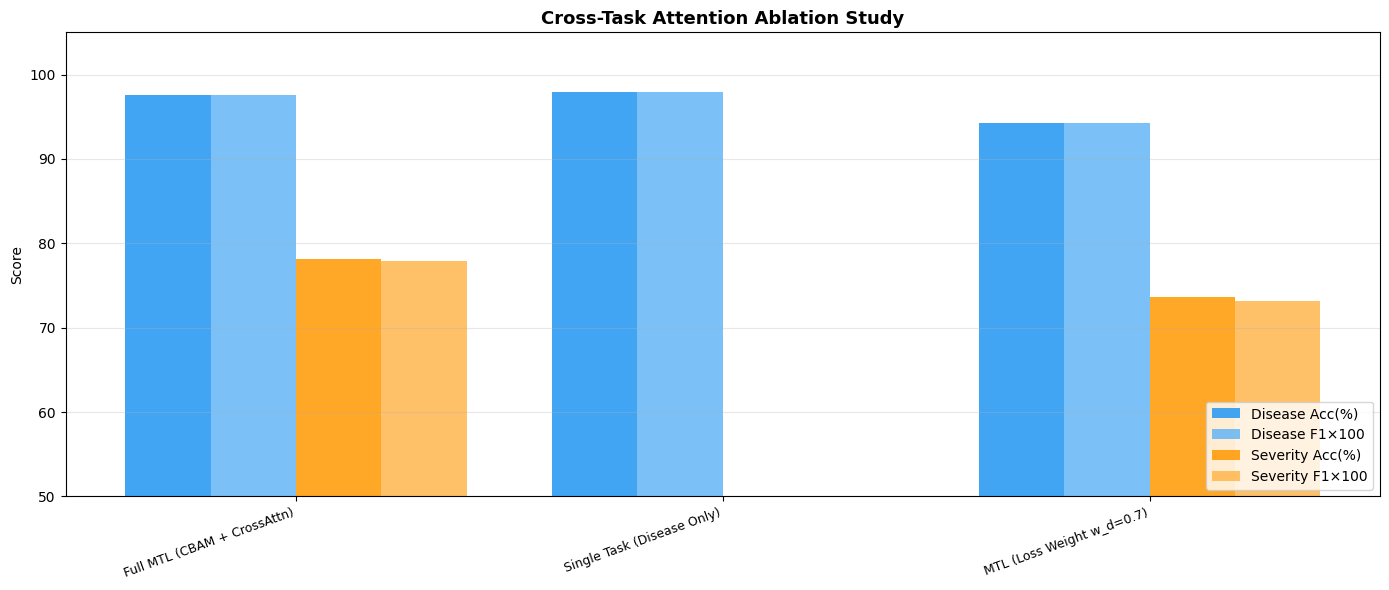

✅ Saved: cross_attn_ablation_results.xlsx + cross_attn_ablation.png


In [ ]:
# ── STEP 3: Final table + plot ─────────────────────────────────
import matplotlib.pyplot as plt

final_df = pd.DataFrame(results)
final_df.to_excel('/content/cross_attn_ablation_results.xlsx', index=False)

print("\n📊 CROSS-TASK ATTENTION ABLATION — FINAL RESULTS")
print(final_df.to_string(index=False))

# Plot
plot_df = final_df[final_df['sev_acc'] != 'N/A'].copy()
plot_df['sev_acc'] = plot_df['sev_acc'].astype(float)
plot_df['sev_f1']  = plot_df['sev_f1'].astype(float)

x = np.arange(len(plot_df)); w = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x-1.5*w, plot_df['dis_acc'],       w, label='Disease Acc(%)',  color='#2196F3', alpha=0.85)
ax.bar(x-0.5*w, plot_df['dis_f1']*100,    w, label='Disease F1×100', color='#64B5F6', alpha=0.85)
ax.bar(x+0.5*w, plot_df['sev_acc'],       w, label='Severity Acc(%)', color='#FF9800', alpha=0.85)
ax.bar(x+1.5*w, plot_df['sev_f1']*100,    w, label='Severity F1×100',color='#FFB74D', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['variant'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(50, 105); ax.set_ylabel('Score')
ax.set_title('Cross-Task Attention Ablation Study', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/cross_attn_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cross_attn_ablation_results.xlsx + cross_attn_ablation.png")

In [ ]:
from google.colab import files
import nbformat

# Upload the notebook you just downloaded
uploaded = files.upload()

# Get filename automatically
filename = list(uploaded.keys())[0]

# Read notebook
nb = nbformat.read(filename, as_version=4)

# Remove widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

# Save cleaned version
clean_name = "clean_" + filename
nbformat.write(nb, clean_name)

print(f"✅ Clean notebook saved as {clean_name}")